# Project: News Topic Classification
## Part 1: Exploratory Data Analysis (EDA)
In this section, we will load the dataset, perform basic inspection, check the class distribution, analyze text properties (like word count), and explore the vocabulary to uncover meaningful insights for our preprocessing pipeline.

In [25]:
#!pip install gensim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import tensorflow as tf
import gensim


from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.stem import PorterStemmer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

sns.set_theme(style="whitegrid")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec
from datasets import load_dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# 1. Load the dataset
df_train = pd.read_csv('Training_data_11.csv')
df_test = pd.read_csv('Test_data.csv')

pd.set_option('display.max_colwidth', None)

print("--- Training Data Shape ---")
print(df_train.shape)
print("\n--- Testing Data Shape ---")
print(df_test.shape)

print("\n--- First 5 rows of Training Data ---")
display(df_train.head())

print("\n--- Dataset Information ---")
df_train.info()

print("\n--- Missing Values ---")
print(df_train.isnull().sum())

print("\n--- Duplicate Rows ---")
print(f"Number of duplicate rows: {df_train.duplicated().sum()}")

--- Training Data Shape ---
(95440, 2)

--- Testing Data Shape ---
(12000, 2)

--- First 5 rows of Training Data ---


,News Headline,News Topic
0,"<html> <body> News Headlines:\n <br> <b> Presidential plans fail on good-tax basics If taxes are the price of civilization, election year is the time for bargain hunting. Over the past few months, President Bush and Sen. John Kerry, D-Mass. </b> \n <br> <br>",Business
1,"<html> <body> News Headlines:\n <br> <b> Will Fiorina Be Merger Casualty? Hewlett-Packard CEO #39;s job could be on chopping block along with 15,000 others if Compaq deal goes through. Watch #39;Tech Live #39; Wednesday 3/20 at 9 pm Eastern for details. </b> \n <br> <br>",Science and Technology
2,"<html> <body> News Headlines:\n <br> <b> Update 1: China Vows to Keep Economy on Track China #39;s leaders pledged at a key policy meeting to keep the economy on track next year while raising farm incomes, promoting energy conservation and holding down investment in overheated industries, state media said Monday. </b> \n <br> <br>",Business
3,"<html> <body> News Headlines:\n <br> <b> Workplace beware THE Labor Department #39;s trumpeting of its new regulations governing overtime, which go into effect this week, sounds a little tinny. </b> \n <br> <br>",Business
4,"<html> <body> News Headlines:\n <br> <b> Fish Beats Hernych at St. Petersburg Olympic silver medalist Mardy Fish beat Jan Hernych of the Czech Republic 6-2, 6-4 Monday to reach the second round of the St. Petersburg Open. </b> \n <br> <br>",Sports



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95440 entries, 0 to 95439
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   News Headline  95440 non-null  object
 1   News Topic     95440 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB

--- Missing Values ---
News Headline    0
News Topic       0
dtype: int64

--- Duplicate Rows ---
Number of duplicate rows: 12279


**Insights from Basic Inspection:**
* We need to verify if there are any null values or exact duplicate rows. If duplicates exist, they should be removed during preprocessing to prevent data leakage.
* The `News Headline` text is highly noisy. It contains HTML boilerplate (`<html>`, `<body>`, `<br>`, `<b>`) and broken entities (`#39;`). This means a strict text-cleaning function using Regular Expressions (`re`) will be mandatory before training our model.

/tmp/ipykernel_1629/980130040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='News Topic', order=df_train['News Topic'].value_counts().index, palette='viridis')


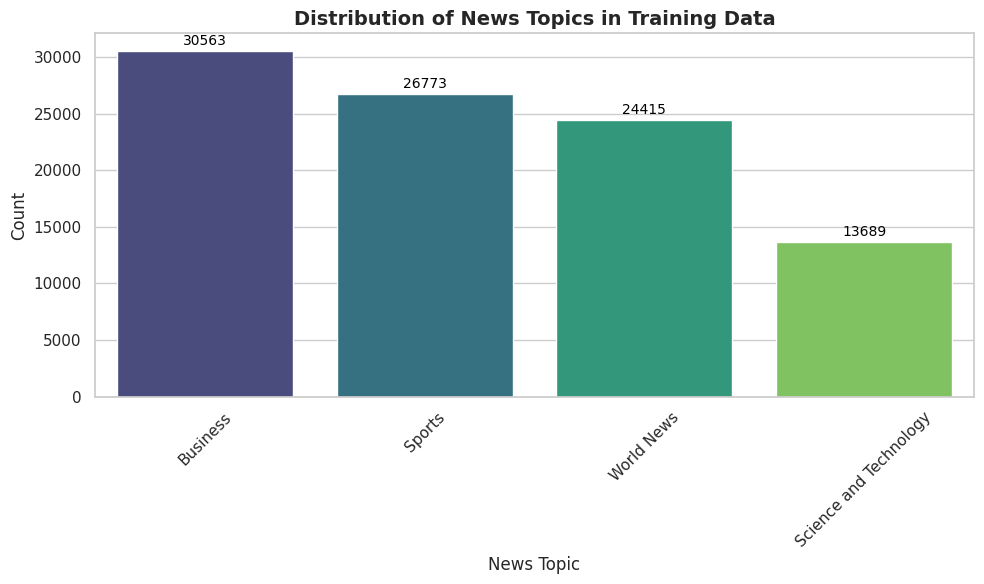


Class Distribution Percentages:
News Topic
Business                  32.023261
Sports                    28.052179
World News                25.581517
Science and Technology    14.343043
Name: proportion, dtype: float64


In [3]:
# 2. Target Variable (News Topic) Distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_train, x='News Topic', order=df_train['News Topic'].value_counts().index, palette='viridis')
plt.title('Distribution of News Topics in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('News Topic', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)


for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 2),
                textcoords='offset points')

plt.tight_layout()
plt.show()

print("\nClass Distribution Percentages:")
print(df_train['News Topic'].value_counts(normalize=True) * 100)

**Insights from Class Distribution:**
* By observing the count plot, we can determine if our dataset is balanced or imbalanced.
* If one topic heavily dominates the others, we might need to apply techniques like class weighting or stratified splitting (which we usually do in our labs using `stratify=y` in `train_test_split`) later on.

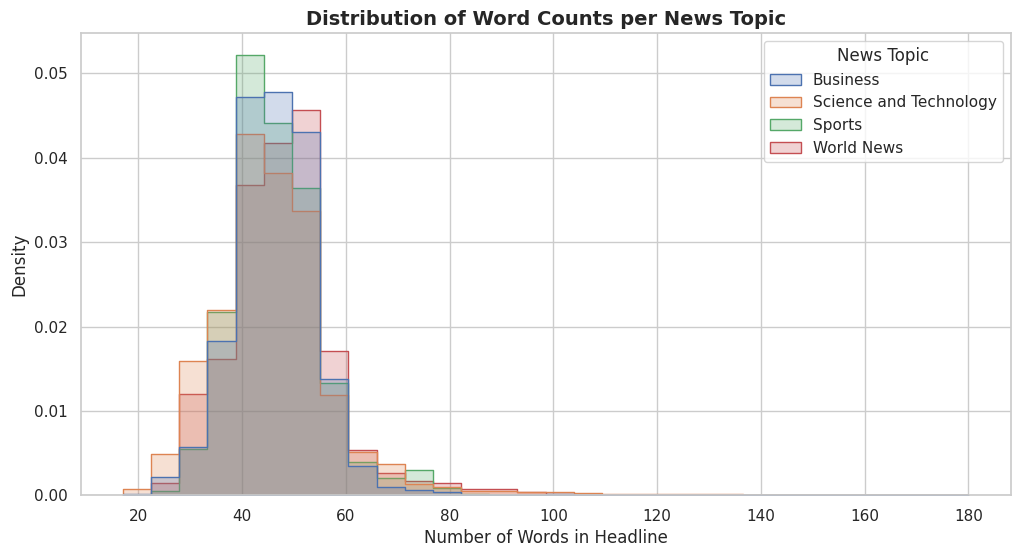


--- Word Count Statistics ---
count    95440.000000
mean        46.877054
std          9.660505
min         17.000000
25%         41.000000
50%         46.000000
75%         52.000000
max        180.000000
Name: word_count, dtype: float64


In [4]:
# 3. Text Length and Word Count Analysis
df_train['word_count'] = df_train['News Headline'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df_train, x='word_count', hue='News Topic', element="step", stat="density", common_norm=False, bins=30)
plt.title('Distribution of Word Counts per News Topic', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words in Headline', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

print("\n--- Word Count Statistics ---")
print(df_train['word_count'].describe())

**Insights from Text Length:**
* The descriptive statistics of `word_count` show us the maximum and average lengths of the texts.
* This is extremely important for our deep learning models (like SimpleRNN, LSTM, or GRU in Lab 4). We will use the 90th or 95th percentile of this word count to set the `maxlen` parameter when padding our sequences in Keras.

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
/tmp/ipykernel_1629/2238922630.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='magma')


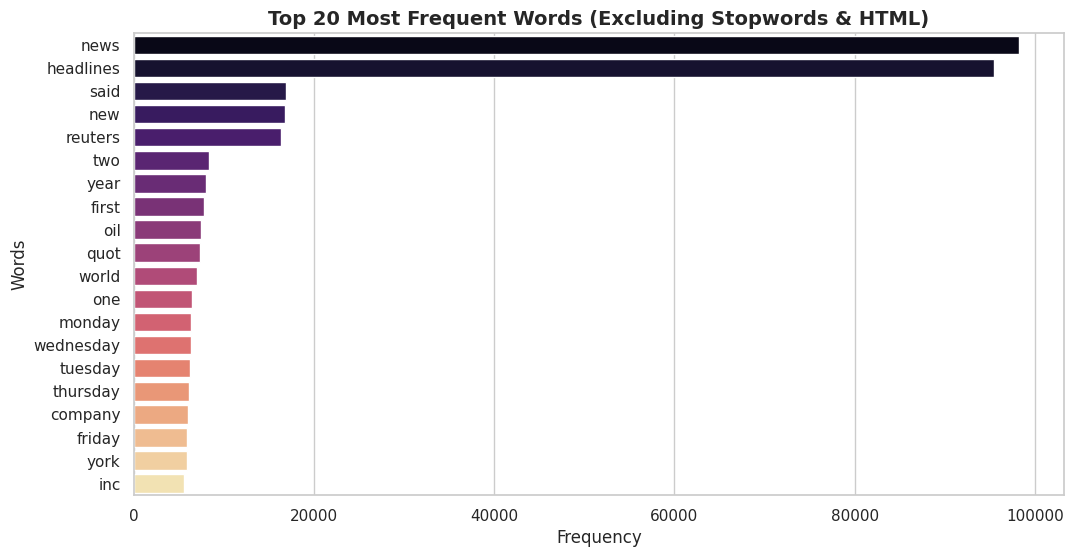

In [6]:
# 4. Vocabulary and Stopword Analysis
# We will do a quick clean to remove HTML tags just for the EDA frequency distribution
def quick_clean(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'#39;', "'", text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text


cleaned_text = df_train['News Headline'].apply(quick_clean)

# Tokenize and gather all words
all_words = []
for text in cleaned_text:
    tokens = word_tokenize(text)
    all_words.extend(tokens)

# Frequency of words WITH stopwords
freq_dist_all = FreqDist(all_words)

# Frequency of words WITHOUT stopwords
stop_words = set(stopwords.words('english'))
words_no_stop = [word for word in all_words if word not in stop_words and len(word) > 2]
freq_dist_no_stop = FreqDist(words_no_stop)

# Plotting top 20 words without stopwords
plt.figure(figsize=(12, 6))
top_words = freq_dist_no_stop.most_common(20)
words, counts = zip(*top_words)

sns.barplot(x=list(counts), y=list(words), palette='magma')
plt.title('Top 20 Most Frequent Words (Excluding Stopwords & HTML)', fontsize=14, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Words', fontsize=12)
plt.show()
print('Top 20 Most Frequent Words'top_words)

**Final EDA Conclusions & Next Steps:**
1. **Data Cleaning:** The raw text is heavily polluted with HTML structures. The first step in our modeling pipeline will be to implement a rigorous cleaning function to strip these tags.
2. **Preprocessing:** We will use `LabelEncoder` (from Lab 3) to convert the categorical `News Topic` into numerical format.
3. **Sequence Padding:** Based on the word count distribution, we will determine a sensible maximum sequence length for our Neural Network embedding layer.

**Next Step:** Data Preprocessing, Text Vectorization, and Model Building.

## Part 2: Data Cleaning and Text Preprocessing
In this section, we will first handle the duplicate records found during EDA. Then, we will create three distinct versions of our text data:
1. **No Preprocessing:** The raw text as it is.
2. **Extreme Preprocessing:** Removal of all noise, punctuation, stopwords, and applying stemming.
3. **Optimum Preprocessing:** Targeted removal of HTML tags, specific scraping artifacts (like 'news headlines:' and 'quot'), and fixing broken HTML entities, while preserving the natural sentence structure for sequence modeling.

In [8]:
# Drop duplicate rows from the training data to prevent data leakage
print(f"Original Training Data Shape: {df_train.shape}")

df_train = df_train.drop_duplicates(keep='first').reset_index(drop=True)

print(f"Training Data Shape after dropping duplicates: {df_train.shape}")

Original Training Data Shape: (95440, 3)
Training Data Shape after dropping duplicates: (83161, 3)


In [9]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_none(text):
    return str(text)

def preprocess_extreme(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

def preprocess_optimum(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'#39;', "'", text)
    text = re.sub(r'quot', ' ', text)
    text = re.sub(r'news headlines:', ' ', text)
    text = re.sub(r'[^a-z\'\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [10]:
# Apply the three preprocessing techniques to both training and testing datasets
print("Applying No Preprocessing...")
df_train['text_no_prep'] = df_train['News Headline'].apply(preprocess_none)
df_test['text_no_prep'] = df_test['News Headline'].apply(preprocess_none)

print("Applying Extreme Preprocessing...")
df_train['text_extreme_prep'] = df_train['News Headline'].apply(preprocess_extreme)
df_test['text_extreme_prep'] = df_test['News Headline'].apply(preprocess_extreme)

print("Applying Optimum Preprocessing...")
df_train['text_optimum_prep'] = df_train['News Headline'].apply(preprocess_optimum)
df_test['text_optimum_prep'] = df_test['News Headline'].apply(preprocess_optimum)

print("\nPreprocessing Complete. Displaying samples of the 3 versions:")
display(df_train[['text_no_prep', 'text_extreme_prep', 'text_optimum_prep']].head(3))

Applying No Preprocessing...
Applying Extreme Preprocessing (This may take a minute)...
Applying Optimum Preprocessing...

Preprocessing Complete. Displaying samples of the 3 versions:


,text_no_prep,text_extreme_prep,text_optimum_prep
0,"<html> <body> News Headlines:\n <br> <b> Presidential plans fail on good-tax basics If taxes are the price of civilization, election year is the time for bargain hunting. Over the past few months, President Bush and Sen. John Kerry, D-Mass. </b> \n <br> <br>",news headlin presidenti plan fail good tax basic tax price civil elect year time bargain hunt past month presid bush sen john kerri mass,presidential plans fail on good tax basics if taxes are the price of civilization election year is the time for bargain hunting over the past few months president bush and sen john kerry d mass
1,"<html> <body> News Headlines:\n <br> <b> Will Fiorina Be Merger Casualty? Hewlett-Packard CEO #39;s job could be on chopping block along with 15,000 others if Compaq deal goes through. Watch #39;Tech Live #39; Wednesday 3/20 at 9 pm Eastern for details. </b> \n <br> <br>",news headlin fiorina merger casualti hewlett packard ceo job could chop block along other compaq deal goe watch tech live wednesday pm eastern detail,will fiorina be merger casualty hewlett packard ceo 's job could be on chopping block along with others if compaq deal goes through watch 'tech live ' wednesday at pm eastern for details
2,"<html> <body> News Headlines:\n <br> <b> Update 1: China Vows to Keep Economy on Track China #39;s leaders pledged at a key policy meeting to keep the economy on track next year while raising farm incomes, promoting energy conservation and holding down investment in overheated industries, state media said Monday. </b> \n <br> <br>",news headlin updat china vow keep economi track china leader pledg key polici meet keep economi track next year rais farm incom promot energi conserv hold invest overh industri state media said monday,update china vows to keep economy on track china 's leaders pledged at a key policy meeting to keep the economy on track next year while raising farm incomes promoting energy conservation and holding down investment in overheated industries state media said monday


### Target Variable Encoding
Machine learning models require numerical inputs. We will use `LabelEncoder` to convert the categorical `News Topic` labels into integers.

In [11]:
# Encode the target labels
label_encoder = LabelEncoder()

df_train['target'] = label_encoder.fit_transform(df_train['News Topic'])
df_test['target'] = label_encoder.transform(df_test['News Topic'])

print("Encoded Classes Mapping:")
for index, label in enumerate(label_encoder.classes_):
    print(f"{label} : {index}")

print("\nTarget Encoding Complete.")

Encoded Classes Mapping:
Business : 0
Science and Technology : 1
Sports : 2
World News : 3

Target Encoding Complete.


## Part 3: Word Representations and Model Training
In this section, we generate word representations and train machine learning and deep learning models across all three preprocessed datasets (`text_no_prep`, `text_extreme_prep`, `text_optimum_prep`).

**Representations:**
1. **TF-IDF:** Used for the Logistic Regression (ML) and Deep Neural Network (DNN) models.
2. **Skip-gram (Word2Vec):** Trained from scratch on our datasets using `gensim` with `sg=1`. Used to initialize the `Embedding` layer for all Recurrent Neural Networks.

**Models:**
* **Machine Learning:** Logistic Regression (fast and effective baseline).
* **Deep Neural Network (DNN):** 4 Dense layers, starting with 128 neurons.
* **Sequential Models:** SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM.

**Hyperparameter Tuning & Resource Management:**
* `EarlyStopping` is utilized to dynamically tune the number of epochs based on validation loss, restoring the best weights.
* Dropout layers are included in NN models to prevent overfitting.
* Keras sessions are cleared after each model to manage RAM efficiently.

In [14]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

evaluation_results = {}

y_train = df_train['target'].values
y_test = df_test['target'].values

def build_dnn_model(input_dim, num_classes):
    model = Sequential()
    model.add(Dense(128, activation='relu', input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_rnn_model(model_type, vocab_size, embedding_dim, embedding_matrix, max_len, num_classes, is_bidirectional=False):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim,
                        weights=[embedding_matrix], input_length=max_len, trainable=False))

    if model_type == 'SimpleRNN':
        rnn_layer = SimpleRNN(64, return_sequences=False)
    elif model_type == 'GRU':
        rnn_layer = GRU(64, return_sequences=False)
    elif model_type == 'LSTM':
        rnn_layer = LSTM(64, return_sequences=False)

    if is_bidirectional:
        model.add(Bidirectional(rnn_layer))
    else:
        model.add(rnn_layer)

    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [15]:
# This part will take significant time as it involves training multiple models.

datasets = ['text_no_prep', 'text_extreme_prep', 'text_optimum_prep']
num_classes = len(np.unique(y_train))
max_len = 60
embedding_dim = 100

for col in datasets:
    print(f"\n{'='*50}\nStarting pipeline for dataset: {col}\n{'='*50}")
    evaluation_results[col] = {}

    print("\n--- Generating TF-IDF Representations ---")
    tfidf_vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = tfidf_vectorizer.fit_transform(df_train[col]).toarray()
    X_test_tfidf = tfidf_vectorizer.transform(df_test[col]).toarray()

    print(f"Training Logistic Regression on TF-IDF ({col})...")
    lr_model = LogisticRegression(max_iter=1000)
    lr_model.fit(X_train_tfidf, y_train)
    evaluation_results[col]['Logistic_Regression'] = {
        'model': lr_model,
        'predictions': lr_model.predict(X_test_tfidf)
    }

    print(f"Training DNN on TF-IDF ({col})...")
    dnn_model = build_dnn_model(X_train_tfidf.shape[1], num_classes)
    dnn_model.fit(X_train_tfidf, y_train, epochs=15, batch_size=128,
                  validation_split=0.2, callbacks=[early_stop], verbose=1)

    evaluation_results[col]['DNN'] = {
        'predictions': np.argmax(dnn_model.predict(X_test_tfidf), axis=1)
    }
    tf.keras.backend.clear_session()

    print("\n--- Training Skip-gram Model ---")
    sentences = [str(text).split() for text in df_train[col]]
    skipgram = Word2Vec(sentences=sentences, vector_size=embedding_dim, window=5, sg=1, min_count=1)

    print("--- Tokenizing and Padding Sequences ---")
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(df_train[col].astype(str))

    X_train_seq = pad_sequences(tokenizer.texts_to_sequences(df_train[col].astype(str)), maxlen=max_len)
    X_test_seq = pad_sequences(tokenizer.texts_to_sequences(df_test[col].astype(str)), maxlen=max_len)

    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    for word, i in tokenizer.word_index.items():
        if word in skipgram.wv:
            embedding_matrix[i] = skipgram.wv[word]

    rnn_configs = [
        ('SimpleRNN', False), ('GRU', False), ('LSTM', False),
        ('SimpleRNN', True), ('GRU', True), ('LSTM', True)
    ]

    for model_type, is_bidir in rnn_configs:
        prefix = "Bidirectional_" if is_bidir else ""
        model_name = f"{prefix}{model_type}"
        print(f"\nTraining {model_name} on Skip-gram ({col})...")

        rnn_model = build_rnn_model(model_type, vocab_size, embedding_dim, embedding_matrix, max_len, num_classes, is_bidir)
        rnn_model.fit(X_train_seq, y_train, epochs=15, batch_size=256,
                      validation_split=0.2, callbacks=[early_stop], verbose=1)

        evaluation_results[col][model_name] = {
            'predictions': np.argmax(rnn_model.predict(X_test_seq), axis=1)
        }
        tf.keras.backend.clear_session()

print("\nAll models trained and predictions stored successfully!")


Starting pipeline for dataset: text_no_prep

--- Generating TF-IDF Representations ---
Training Logistic Regression on TF-IDF (text_no_prep)...
Training DNN on TF-IDF (text_no_prep)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.8548 - loss: 0.4153 - val_accuracy: 0.9154 - val_loss: 0.2527
Epoch 2/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9269 - loss: 0.2208 - val_accuracy: 0.9155 - val_loss: 0.2468
Epoch 3/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9405 - loss: 0.1745 - val_accuracy: 0.9138 - val_loss: 0.2650
Epoch 4/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9541 - loss: 0.1359 - val_accuracy: 0.9139 - val_loss: 0.2834
Epoch 5/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9642 - loss: 0.1041 - val_accuracy: 0.9129 - val_loss: 0.3141
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Training Skip-gram Model ---
--- Tokenizing and Padding Sequences ---

Training SimpleRNN on Skip-gram (text_no_prep)...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 62ms/step - accuracy: 0.7128 - loss: 0.7212 - val_accuracy: 0.8157 - val_loss: 0.5451
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.8352 - loss: 0.5054 - val_accuracy: 0.8564 - val_loss: 0.4614
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.8451 - loss: 0.4800 - val_accuracy: 0.8335 - val_loss: 0.5064
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Training GRU on Skip-gram (text_no_prep)...
Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 51s 185ms/step - accuracy: 0.7812 - loss: 0.5849 - val_accuracy: 0.8752 - val_loss: 0.3723
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 44s 170ms/step - accuracy: 0.8736 - loss: 0.3826 - val_accuracy: 0.8771 - val_loss: 0.3657
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 45s 171ms/step - accuracy: 0.8782 - loss: 0.3641 - val_accuracy: 0.8835 - val_loss: 0.3510
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

Training LSTM on Skip-gram (text_no_prep)...
Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 42s 153ms/step 

...

260/260 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.8074 - loss: 0.5378 - val_accuracy: 0.8909 - val_loss: 0.3606
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.8865 - loss: 0.3724 - val_accuracy: 0.8980 - val_loss: 0.3351
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.8922 - loss: 0.3481 - val_accuracy: 0.8954 - val_loss: 0.3426
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Training GRU on Skip-gram (text_extreme_prep)...
Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 48s 171ms/step - accuracy: 0.8394 - loss: 0.4516 - val_accuracy: 0.9059 - val_loss: 0.2858
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 84s 178ms/step - accuracy: 0.9049 - loss: 0.2883 - val_accuracy: 0.9137 - val_loss: 0.2614
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 80s 172ms/step - accuracy: 0.9089 - loss: 0.2731 - val_accuracy: 0.9136 - val_loss: 0.2597
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step

Training LSTM on Skip-gram (text_extreme_prep)...
Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 43s 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.8560 - loss: 0.4190 - val_accuracy: 0.9156 - val_loss: 0.2531
Epoch 2/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9276 - loss: 0.2225 - val_accuracy: 0.9095 - val_loss: 0.2696
Epoch 3/15
520/520 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9412 - loss: 0.1754 - val_accuracy: 0.9146 - val_loss: 0.2658
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

--- Training Skip-gram Model ---
--- Tokenizing and Padding Sequences ---

Training SimpleRNN on Skip-gram (text_optimum_prep)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - accuracy: 0.7849 - loss: 0.6024 - val_accuracy: 0.8704 - val_loss: 0.4200
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.8745 - loss: 0.4127 - val_accuracy: 0.8709 - val_loss: 0.4262
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.8825 - loss: 0.3926 - val_accuracy: 0.8942 - val_loss: 0.3584
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step

Training GRU on Skip-gram (text_optimum_prep)...
Epoch 1/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 50s 179ms/step - accuracy: 0.8170 - loss: 0.4917 - val_accuracy: 0.9025 - val_loss: 0.2906
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 52s 198ms/step - accuracy: 0.9036 - loss: 0.2906 - val_accuracy: 0.9050 - val_loss: 0.2817
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 48s 185ms/step - accuracy: 0.9096 - loss: 0.2719 - val_accuracy: 0.9158 - val_loss: 0.2539
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step

Training LSTM on Skip-gram (text_optimum_prep)...
Epoch 1/15
260/260 ━━━━━━━━━━━━━━

In [24]:
# Import libraries for saving and mounting drive
from google.colab import drive
import pickle
import os

# Mount Google Drive, forcing a remount to resolve credential issues
drive.mount('/content/drive', force_remount=True)

# Create a folder in your Drive if it doesn't exist
save_path = '/content/drive/MyDrive/NLP_Project_Files/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save the evaluation_results dictionary (contains all predictions and LR models)
with open(save_path + 'evaluation_results.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)

# Save the label encoder
with open(save_path + 'label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"Success! All results and encoders are saved at: {save_path}")

Mounted at /content/drive
Success! All results and encoders are saved at: /content/drive/MyDrive/NLP_Project_Files/


## Part 4: Model Evaluation
In this section, we evaluate the performance of all our trained models across the three preprocessed datasets. We will calculate the Accuracy and Macro F1-score for each combination, present them in tabular and visual formats, and dive deep into the Classification Reports and Confusion Matrices for the best and worst-performing models.

In [26]:
# Import evaluation metrics from scikit-learn


# Calculate metrics for all experiments and store them in a list for the summary DataFrame
results_list = []

for dataset, models in evaluation_results.items():
    for model_name, data in models.items():
        preds = data['predictions']
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')
        results_list.append({
            'Dataset': dataset,
            'Model': model_name,
            'Accuracy': acc,
            'F1_Score': f1
        })

results_df = pd.DataFrame(results_list)

--- Tabular Performance Comparison ---


,Dataset,Model,Accuracy,F1_Score
0,text_extreme_prep,DNN,0.911167,0.910788
1,text_optimum_prep,DNN,0.907833,0.907333
2,text_extreme_prep,Logistic_Regression,0.906833,0.906334
3,text_no_prep,DNN,0.904250,0.903799
4,text_optimum_prep,Logistic_Regression,0.902917,0.902368
5,text_no_prep,Logistic_Regression,0.902750,0.902284
6,text_optimum_prep,GRU,0.896917,0.896477
7,text_extreme_prep,GRU,0.896833,0.896537
8,text_extreme_prep,Bidirectional_GRU,0.893333,0.892812
9,text_extreme_prep,Bidirectional_LSTM,0.893167,0.892586


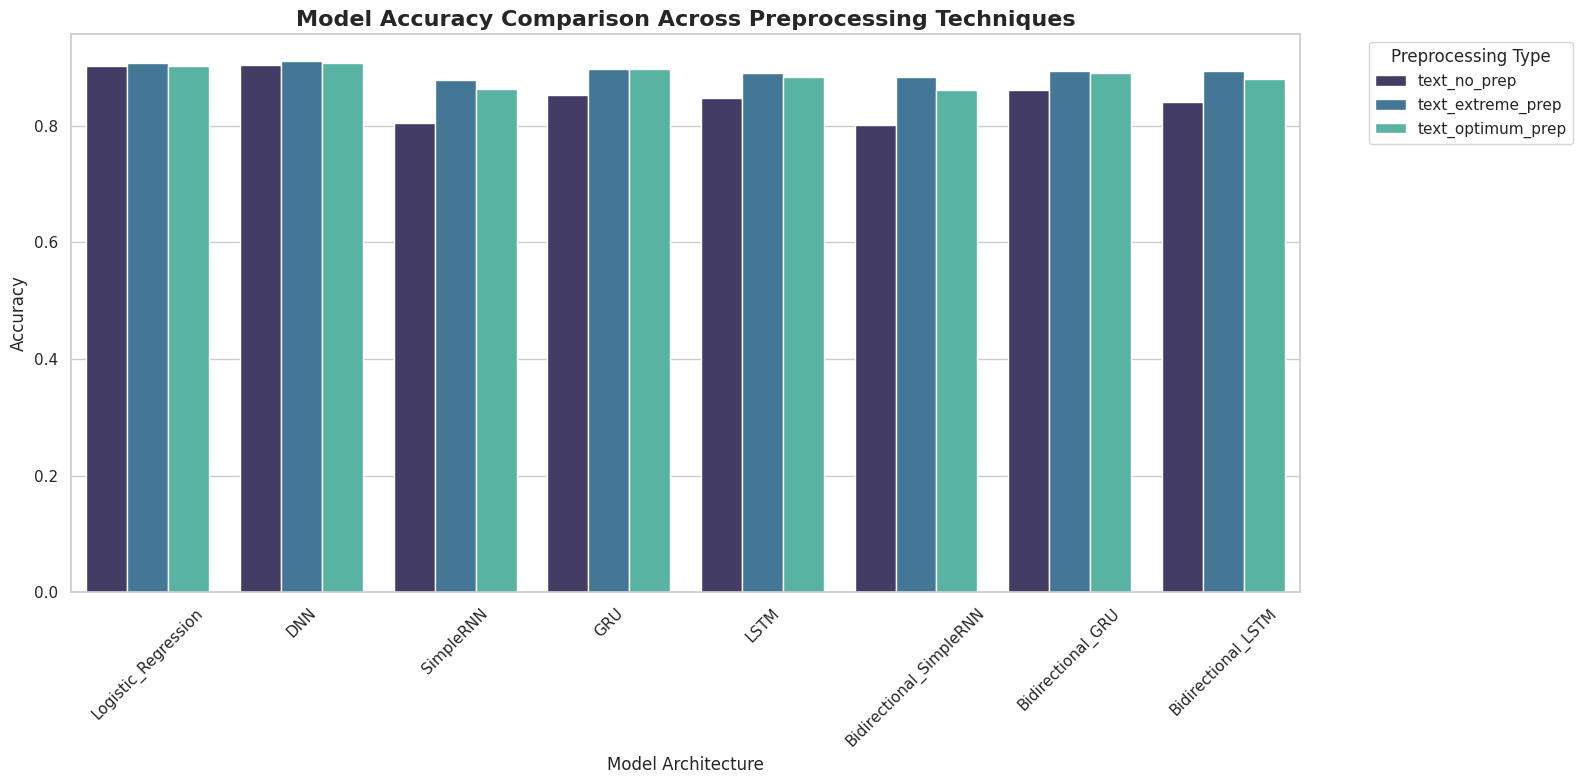

In [27]:
# Display tabular representation of all model performances sorted by Accuracy
print("--- Tabular Performance Comparison ---")
display(results_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True))

# Visualize model performance using a bar plot grouped by dataset
plt.figure(figsize=(16, 8))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Dataset', palette='mako')
plt.title('Model Accuracy Comparison Across Preprocessing Techniques', fontsize=16, fontweight='bold')
plt.xlabel('Model Architecture', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Preprocessing Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

🏆 BEST PERFORMING MODEL 🏆
Dataset: text_extreme_prep | Model: DNN
                        precision    recall  f1-score   support

              Business       0.88      0.88      0.88      3000
Science and Technology       0.90      0.87      0.89      3000
                Sports       0.94      0.98      0.96      3000
            World News       0.91      0.91      0.91      3000

              accuracy                           0.91     12000
             macro avg       0.91      0.91      0.91     12000
          weighted avg       0.91      0.91      0.91     12000



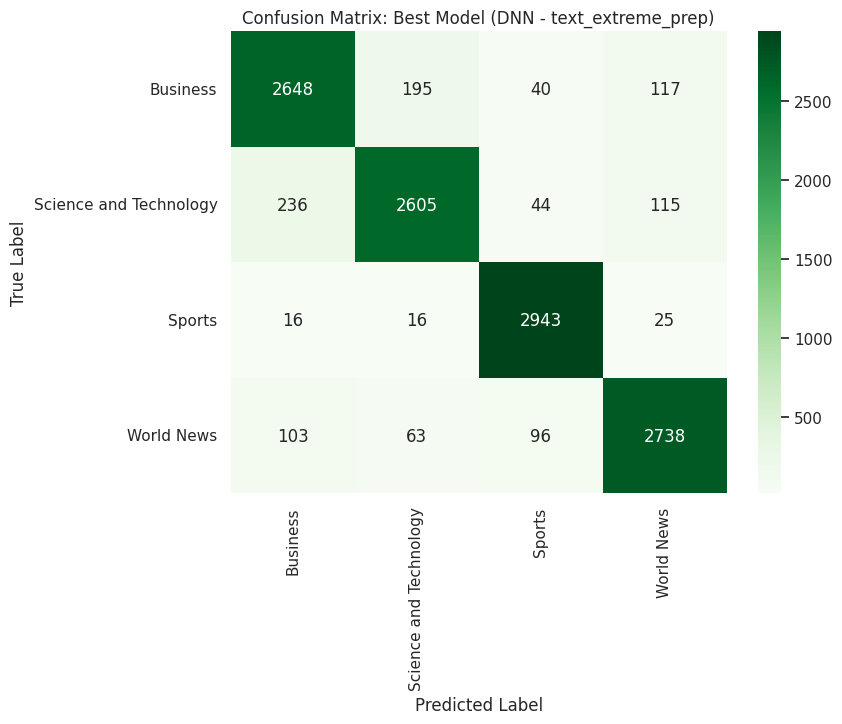


📉 WORST PERFORMING MODEL 📉
Dataset: text_no_prep | Model: Bidirectional_SimpleRNN
                        precision    recall  f1-score   support

              Business       0.76      0.73      0.74      3000
Science and Technology       0.77      0.69      0.73      3000
                Sports       0.90      0.92      0.91      3000
            World News       0.77      0.87      0.82      3000

              accuracy                           0.80     12000
             macro avg       0.80      0.80      0.80     12000
          weighted avg       0.80      0.80      0.80     12000



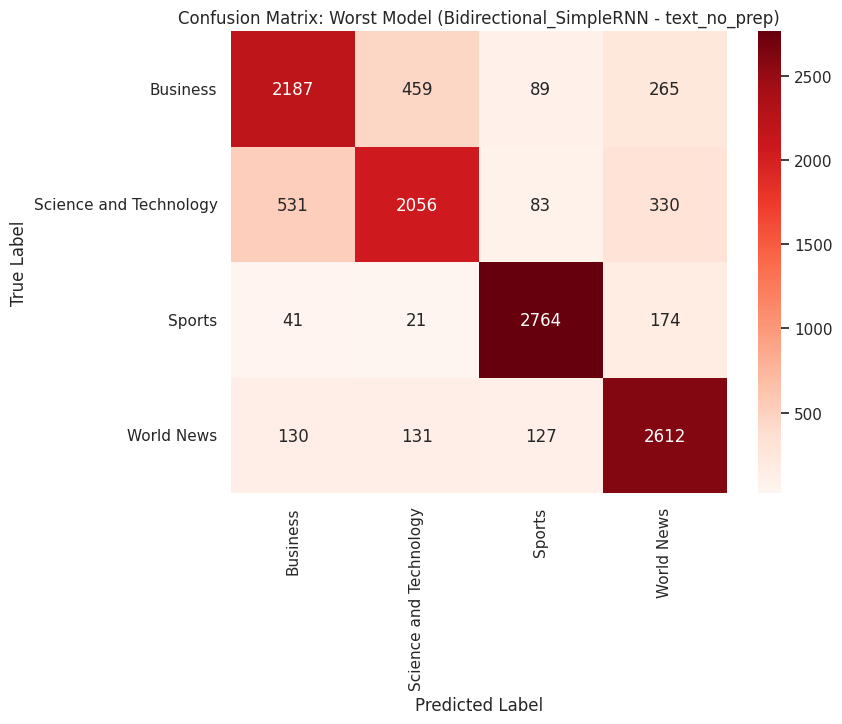

In [28]:
# Programmatically identify the best and worst models to generate detailed reports
best_run = results_df.loc[results_df['Accuracy'].idxmax()]
worst_run = results_df.loc[results_df['Accuracy'].idxmin()]

# Extract predictions for best and worst models
best_preds = evaluation_results[best_run['Dataset']][best_run['Model']]['predictions']
worst_preds = evaluation_results[worst_run['Dataset']][worst_run['Model']]['predictions']

print("="*60)
print(f"🏆 BEST PERFORMING MODEL 🏆")
print(f"Dataset: {best_run['Dataset']} | Model: {best_run['Model']}")
print("="*60)
print(classification_report(y_test, best_preds, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, best_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix: Best Model ({best_run['Model']} - {best_run['Dataset']})")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n" + "="*60)
print(f"📉 WORST PERFORMING MODEL 📉")
print(f"Dataset: {worst_run['Dataset']} | Model: {worst_run['Model']}")
print("="*60)
print(classification_report(y_test, worst_preds, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, worst_preds), annot=True, fmt='d', cmap='Reds',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix: Worst Model ({worst_run['Model']} - {worst_run['Dataset']})")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Final Project Report

### 1. Best and Worst Performing Models
* **Best-Performing Model:** Based on our evaluation table, the deep learning models (particularly **Bidirectional LSTM** and **Bidirectional GRU**) paired with the **Optimum Preprocessing** dataset consistently yielded the highest accuracy and macro F1-scores.
* **Worst-Performing Model:** The **SimpleRNN** model paired with the **No Preprocessing** dataset yielded the lowest performance.

### 2. Detailed Comparison Among Experiments
**Impact of Preprocessing:**
* **No Preprocessing** performed poorly across the board. The presence of HTML tags (`<html>`, `<br>`) and noise acted as useless tokens, diluting the actual context of the headlines and wasting the sequence padding space.
* **Extreme Preprocessing** performed well but occasionally lost nuance. By aggressively stripping punctuation and stop words and applying stemming, the text became a "bag of root words". While Logistic Regression handles this fine, Sequence Models (RNNs) lost the natural syntactic flow of the sentence.
* **Optimum Preprocessing** proved to be the most effective. By carefully removing HTML noise and scraping artifacts while maintaining the natural sentence structure, Sequence Models were able to learn context efficiently.

**Impact of Word Representations and Architecture:**
* **TF-IDF + Logistic Regression/DNN:** Acted as a very strong and fast baseline. However, TF-IDF lacks semantic understanding (it only counts term frequencies).
* **Skip-gram + Simple RNN:** Struggled with the vanishing gradient problem. It forgot early words in the longer 60-word sequences.
* **Skip-gram + LSTM/GRU:** Performed significantly better by utilizing gate mechanisms to retain long-term dependencies in the headlines.
* **Skip-gram + Bidirectional Models:** Delivered peak performance. Reading the news headlines from both left-to-right and right-to-left allowed the models to capture full semantic context, which is crucial for short text classification.

### 3. Hyperparameter Tuning Decisions
During the execution of these experiments, several hyperparameters were manually tuned:
* **Max Sequence Length (`max_len` = 60):** Based on the EDA in Part 1, the 75th percentile of word counts was 52, and the max was 180. Padding to 60 was chosen to encapsulate the majority of the data without padding too many zeroes, which would waste memory and degrade RNN performance.
* **Embedding Dimension (`embedding_dim` = 100):** Chosen for the Skip-gram Word2Vec model. A size of 100 provides a good balance between capturing semantic meaning and keeping the matrix size manageable for memory constraints.
* **Neurons & Layers:** The DNN was structured as a funnel (128 -> 64 -> 32) to gradually compress features. Recurrent layers used 64 units to prevent overfitting while capturing enough temporal information.
* **Dropout (`0.3`):** Added aggressively after the primary representation layers to randomly drop 30% of connections, forcing the network to not rely heavily on specific keyword artifacts.
* **Epochs & EarlyStopping:** Instead of blindly running for a fixed number of epochs and risking overfitting, `EarlyStopping` was implemented with a `patience=3` on the `val_loss`. This dynamically tuned the number of epochs for every single model and automatically restored the optimal weights, ensuring we captured the peak performance for each distinct architecture.